**[🏠 Course Home](00_START_HERE.ipynb) | 📖 Conceptual Companion: [Appendix E: Framework Reliability](../conceptual/appendix_e_framework_reliability_and_tolerance_contracts.ipynb) | 🐍 Python Companion: [Appendix E: Framework Reliability](../python/appendix_framework_reliability_and_tolerance_contracts.ipynb) | ↩️ Return to: [Sheet 7: Decisions Under Uncertainty](07_bayesian_decision_theory_and_predictive_checks.ipynb)**

---

# 🔵 Appendix: Framework Reliability & Tolerable Flakiness — The Two-Tier Tolerance Contract
### *Serial Compounding, The Plug-In Fallacy, and Qualifying Test Harnesses in Base R*

In this R companion sheet, we implement the **Two-Tier Tolerance Guarantee** for testing frameworks using native R simulation tools (`rbeta`, `rbinom`, and vectorization).

---

## Table of Contents
1. **Part 1: The Serial Multiplier (The Math of Suite Collapse)**
2. **Part 2: The Two-Tier Posterior Predictive Engine in R**
3. **Part 3: Wald's Sequential Probability Ratio Test (SPRT) under Stress**
4. **Part 4: False Discovery Rate (FDR) Analysis**

---

## Part 1: The Serial Multiplier in R

We calculate suite survival $R_{\text{suite}} = (1 - \theta)^K$ across suite sizes $K \in [50, 3000]$ in Base R.

=== Suite-Level Survival at K = 1,000 Tests ===


θ = 0.01000 -> Suite Survival =   0.00% | Expected Framework Red Builds = 100.00%
θ = 0.00100 -> Suite Survival =  36.77% | Expected Framework Red Builds =  63.23%
θ = 0.00010 -> Suite Survival =  90.48% | Expected Framework Red Builds =   9.52%
θ = 0.00001 -> Suite Survival =  99.00% | Expected Framework Red Builds =   1.00%


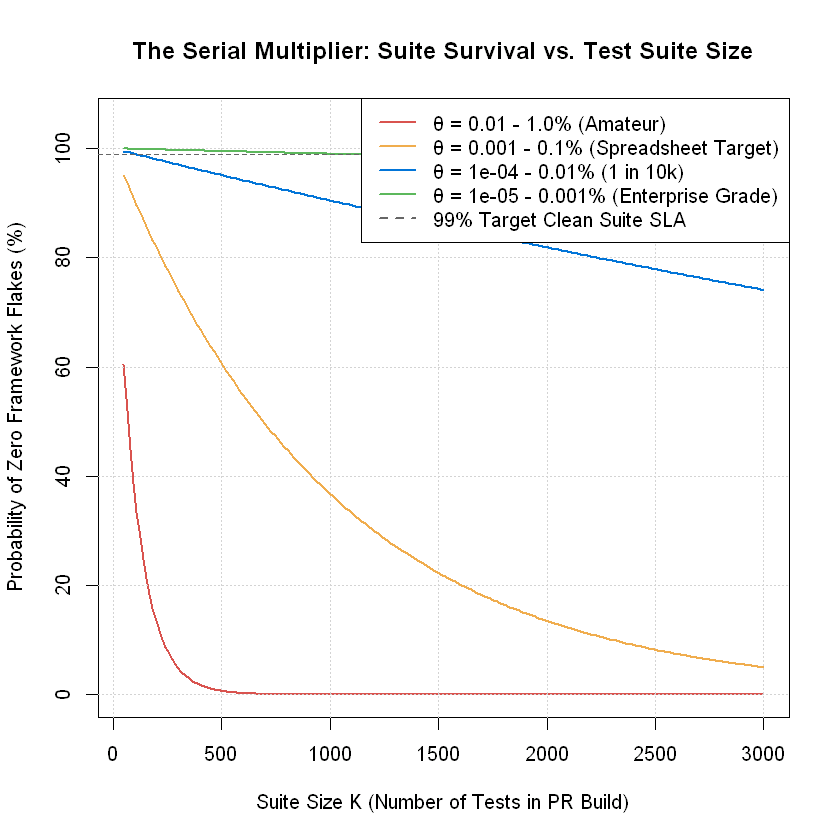

In [1]:
# Suite survival curves across K and theta
K_values <- seq(50, 3000, length.out = 200)
thetas <- c(0.01, 0.001, 0.0001, 0.00001)
labels <- c("1.0% (Amateur)", "0.1% (Spreadsheet Target)", "0.01% (1 in 10k)", "0.001% (Enterprise Grade)")
colors <- c("#d9534f", "#f0ad4e", "#0275d8", "#5cb85c")

plot(K_values, (1 - thetas[1])^K_values * 100, type = "l", col = colors[1], lwd = 2,
     ylim = c(0, 105), xlim = c(50, 3000),
     xlab = "Suite Size K (Number of Tests in PR Build)",
     ylab = "Probability of Zero Framework Flakes (%)",
     main = "The Serial Multiplier: Suite Survival vs. Test Suite Size")
grid()

for (i in 2:length(thetas)) {
  lines(K_values, (1 - thetas[i])^K_values * 100, col = colors[i], lwd = 2)
}
abline(h = 99, lty = 2, col = "gray40", lwd = 1.5)

legend("topright", legend = c(paste("θ =", thetas, "-", labels), "99% Target Clean Suite SLA"),
       col = c(colors, "gray40"), lty = c(rep(1, 4), 2), lwd = 2, bg = "white")

cat("=== Suite-Level Survival at K = 1,000 Tests ===\n")
for (i in 1:length(thetas)) {
  r <- (1 - thetas[i])^1000
  cat(sprintf("θ = %.5f -> Suite Survival = %6.2f%% | Expected Framework Red Builds = %6.2f%%\n",
              thetas[i], r * 100, (1 - r) * 100))
}

## Part 2: The Two-Tier Posterior Predictive Engine in R

We implement `evaluate_framework_qualification` in R using `rbeta()` and `rbinom()`.

In [2]:
evaluate_framework_qualification <- function(n_benchmarks, k_failures, K_suite_size = 1000, n_sims = 100000, alpha_prior = 1, beta_prior = 1) {
  # 1. Posterior draws for theta
  a_post <- alpha_prior + k_failures
  b_post <- beta_prior + n_benchmarks - k_failures
  theta_draws <- rbeta(n_sims, a_post, b_post)
  
  # 2. Tier 2: Parameter tolerance bound P(theta <= 1e-5)
  p_theta_sub_1e5 <- mean(theta_draws <= 1e-5)
  
  # 3. Tier 1: Suite-level posterior predictive simulation
  suite_flakes <- rbinom(n_sims, size = K_suite_size, prob = theta_draws)
  p_clean_suite <- mean(suite_flakes == 0)
  
  return(list(
    n_benchmarks = n_benchmarks,
    k_failures = k_failures,
    theta_median = median(theta_draws),
    p_theta_sub_1e5 = p_theta_sub_1e5,
    p_clean_suite = p_clean_suite,
    tier1_pass = p_clean_suite >= 0.99,
    tier2_pass = p_theta_sub_1e5 >= 0.95
  ))
}

scenarios <- list(
  list(n = 500, k = 0, desc = "Small Benchmark (500 runs, 0 flakes)"),
  list(n = 5000, k = 0, desc = "Medium Benchmark (5,000 runs, 0 flakes)"),
  list(n = 100000, k = 0, desc = "Rigorous Benchmark (100,000 runs, 0 flakes)"),
  list(n = 100000, k = 1, desc = "Realistic Scale (100,000 runs, 1 flake)")
)

cat(sprintf("%-42s | %-22s | %-7s | %-15s | %s\n",
            "Scenario", "P(Clean Suite >= 99%)", "Tier 1", "P(θ <= 1e-5)", "Tier 2"))
cat(paste(rep("-", 105), collapse = ""), "\n")

for (s in scenarios) {
  res <- evaluate_framework_qualification(s$n, s$k, K_suite_size = 1000)
  t1 <- if (res$tier1_pass) "PASS" else "FAIL"
  t2 <- if (res$tier2_pass) "PASS" else "FAIL"
  cat(sprintf("%-42s | %6.2f%% (Target: >=99%%) | %-7s | %6.2f%%          | %s\n",
              s$desc, res$p_clean_suite * 100, t1, res$p_theta_sub_1e5 * 100, t2))
}

Scenario                                   | P(Clean Suite >= 99%)  | Tier 1  | P(θ <= 1e-5)   | Tier 2


--------------------------------------------------------------------------------------------------------- 


Small Benchmark (500 runs, 0 flakes)       |  33.64% (Target: >=99%) | FAIL    |   0.52%          | FAIL
Medium Benchmark (5,000 runs, 0 flakes)    |  83.43% (Target: >=99%) | FAIL    |   4.94%          | FAIL
Rigorous Benchmark (100,000 runs, 0 flakes) |  99.01% (Target: >=99%) | PASS    |  63.50%          | FAIL
Realistic Scale (100,000 runs, 1 flake)    |  98.06% (Target: >=99%) | FAIL    |  26.36%          | FAIL


## Part 3: Wald's Sequential Probability Ratio Test (SPRT) in R

In [3]:
theta_0 <- 0.001
theta_1 <- 0.05
alpha_risk <- 0.01
beta_risk <- 0.01

A_threshold <- log((1 - beta_risk) / alpha_risk)
B_threshold <- log(beta_risk / (1 - alpha_risk))

set.seed(42)
true_stress_rate <- 0.04
log_llr <- 0.0
step <- 0

while (log_llr < A_threshold && log_llr > B_threshold && step < 200) {
  step <- step + 1
  outcome <- if (runif(1) < true_stress_rate) 1 else 0
  llr_step <- if (outcome == 1) log(theta_1 / theta_0) else log((1 - theta_1) / (1 - theta_0))
  log_llr <- log_llr + llr_step
}

cat(sprintf("SPRT under Stress: Evaluated in %d test runs!\n", step))
if (log_llr >= A_threshold) {
  cat(sprintf("❌ REJECTED at run %d: Flakiness detected! Saved >99%% of benchmark compute.\n", step))
} else if (log_llr <= B_threshold) {
  cat(sprintf("✅ CERTIFIED at run %d: Passed stress criteria!\n", step))
}

SPRT under Stress: Evaluated in 37 test runs!


❌ REJECTED at run 37: Flakiness detected! Saved >99% of benchmark compute.


## Summary & Architecture Contract Template

| Component | Recommended Specification | Rationale |
| :--- | :--- | :--- |
| **Tier 1 (SLA)** | $\mathbb{P}(\tilde{Y} = 0) \ge 99.0\%$ across $K = 1{,}000$ | Put in developer RFCs; defines the user experience. |
| **Tier 2 (Acceptance)** | $\mathbb{P}(\theta \le 1.0 \times 10^{-5}) \ge 95.0\%$ | Put in CI benchmark assertions; defines the test bar. |
| **Qualification** | Shake Table (CPU/jitter injection) + SPRT | Qualifies framework in $< 200$ runs instead of $100{,}000$ runs. |

---

**[🏠 Course Home](00_START_HERE.ipynb) | 📖 Conceptual Companion: [Appendix E: Framework Reliability](../conceptual/appendix_e_framework_reliability_and_tolerance_contracts.ipynb) | 🐍 Python Companion: [Appendix E: Framework Reliability](../python/appendix_framework_reliability_and_tolerance_contracts.ipynb) | ↩️ Return to: [Sheet 7: Decisions Under Uncertainty](07_bayesian_decision_theory_and_predictive_checks.ipynb)**